## Load necessary Python packages

To be able to load necessary packages, please install all the dependencies listed in requirements.txt and also install sigkernel repository by using 'pip install git+https://github.com/crispitagorico/sigkernel.git'. 

If above is done, we can now go ahead. 

In [2]:
import torch, sys
from scipy import stats
import numpy as np
import pylab as plt

Matplotlib is building the font cache; this may take a moment.


## Define signature kernel scoring rule as negative loglikelihood 

Notice here we import SignatureKernel from mysrc.scoring_rules file located in our mysrc folder. To define the SignatureKernel we need to choose to tuning parameters, dyadic order (related to numerical accuracy of a PDE solver as the signature kernel computation involves solving a Gourset PDE) and rbf_sigma (the bandwith parameter for the static kernel, here chosen radial basis function). In this work we choose dyadic order to be 1 as we didn't observe much affect in results except becoming more expensive. We also further have chosen rbf_sigma as 0.1 for this case.  

In [5]:
from mysrc.scoring_rules import SignatureKernel
neg_approx_llhd = SignatureKernel(rbf_sigma=.1, dyadic_order = 1, keep_time = True, cumsum=False, static_kernel_name='RBF').estimate_score_batch

## Load dataset we are going to analyse

In this case we load one replicate from the Drosophila dataset, in which we had 10 replicates available. For this illustrative analysis we have chosen the first replicate (rep_ind=1). This is an allele-frequency dataset recorded at 'm' locations and over 'g' generations (including the initial generation). We further notice that the dataset should be a 3-dimensional matrix, 1st dimension stands for different generations (length 'g'), 2nd dimension stands for number of replicates (length 1 as we consider one replicate), 3rd dimension stands for generations and allele frequency at all locations (length 1+'m' as we have 'm' locations). The values of intermediate generations are always considered to be between 0 and 1, whereas initial and final generations are denoted as 0 and 1. 

For this specific dataset, we have 7 generations and 3 locations. As we consider only one replicate, the dataset should be a 7x1x4 matrix. 

In [6]:
rep_ind = 1
Drosophila_data = torch.tensor(np.load('Data/Drosophila/Drosophila.npz')['data']).double()
Drosophila_data_one = Drosophila_data[:,rep_ind,:].reshape(7, 1, 4)

## Define the simulator model

Here we define the simulator model, in this case Wright-Fisher model. This is defined by first importing the function WFUniformDirichlet as WFUD, which lets us simulate from Wright-Fisher model for a parameter (the selection coefficients and initial haplotype frequency). In addition this function also assigns an Uniform prior (U[-0.2, 0.2]) on each of the selection coefficients and a Dirichlet distribution on the initial haplotype frequency. 

To define the simulator model, we need to specify some other parameters, population_size (300 for this dataste), generation (total number of generations, 60 in this case) generation_interval (number of generations between the generations where we collected the allel frequency data, 10 in this case), recomb_param (the recombination parameter, n_param (number of locations under study, in this case 3), hich we choose as [[(0.03/1000000)*(1610748-1541936), (0.03/1000000)*(2387650-1610748)]] based on the distance between the locations under study on the chromosome), data_obs (the data we are going to study, in this case the Drosophila data) and finally define the negative loglikelihood for the simulator model by supplying neg_approx_llhd we defined before using the signature kernel scoring rule.

In [7]:
from mysrc.ModelWF import WFUniformDirichlet as WFUD

WFUD= WFUD(neg_approx_llhd, population_size=300, generation=60, generation_interval=[10],
                 recomb_param=[(0.03/1000000)*(1610748-1541936), (0.03/1000000)*(2387650-1610748)], 
                 data_obs=Drosophila_data_one, n_sample=100, n_param=3)

Once this is done, we define the log posterior for a parameter (defined as x) given the observed data. 

In [8]:
lpost = lambda x: WFUD.llhd_grad(x) + WFUD.logprior_grad(x)

## LLS estimate of selection coefficients

We first compute LLS estimate of the selection coefficinets, which would be used to define the starting point of the MCMC chain. 

In [9]:
estimate_lls = np.zeros(shape=(1, 3))

data_obs_tmp_numpy = Drosophila_data_one.detach().numpy().squeeze()
for ind_dim in range(data_obs_tmp_numpy.shape[1]-1):
        nonzero_index = np.argwhere(data_obs_tmp_numpy[:,ind_dim+1]>0).max()
        p_t, p_0 = data_obs_tmp_numpy[nonzero_index,ind_dim+1],data_obs_tmp_numpy[0,ind_dim+1]
        if p_t == 0:
            p_t = 1e-10
        if p_t == 1.0:
            p_t = 1.0 - 1e-10
        if p_t == p_0:
            estimate_lls[0, ind_dim] = 0
        if p_t == p_0:
            estimate_lls[0, ind_dim] = 0
        else:
            estimate_lls[0, ind_dim] = (np.log((p_t * (1-p_0))/(p_0*(1-p_t))))*(2/(10*nonzero_index))

print('Estimated selection coefficients by LLS:', estimate_lls)

Estimated selection coefficients by LLS: [[ 0.00113777 -0.00329215 -0.03723205]]


## Metropolis-Hasting algorithm to sample from the scoring rule posterior

First we import the algorithm 'MH' implemented in mysrc.MH. As MH algorithm is optimally run on $\mathbb{R}^d$, we transform our parameters to $\mathbb{R}^d$ using change of varaible formula. To run MH, we need to provide a starting point for the Markov chain and a covariance matrix defining the proposal zero-mean multivariate Gaussian distribution. 

As our parameter contains selection coefficients and initial haplotype frequencies, we consider LLS estimate and an initial haplotype frequency with equal weights in all dimensions to define the starting point of our Markov chain. Further we also transform them to $\mathbb{R}^d$ as the MH would be run on $\mathbb{R}^d$, this transformation is provided by the simulator model. 

In [11]:
from mysrc.MH import MH

x0 = WFUD.transformationtoR(torch.tensor(estimate_lls[0, :].tolist() +[0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25]))

Next we define a covariance matrix for the proposal zero-mean multivariate Gaussian distribution. We consider an identity matrix multiplied by a chosen scaling coefficient (in this case we chose 5e-3) to keep the acceptance rate between .2-.4

In [ ]:
sigma_0 = 5e-3 * torch.tensor([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                              [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                              [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
                              [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
                              [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
                              [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                              [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
                              [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
                              [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
                              [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
                              [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]], dtype=torch.float64)

Next we run the MH to simulate a Markov chain on $\mathbb{R}^d$ targeting the scoring rule posterior. The chain was run for nmoves (100000) many steps, we retun the entire chain, adapt (if adapt is True) the covariance matrix after each adapt_no (chosen 1000) many steps following the scheme described [here](https://projecteuclid.org/journals/bernoulli/volume-7/issue-2/An-adaptive-Metropolis-algorithm/bj/1080222083.full)

In [ ]:
xx = MH(lpost, x0 = x0,sigma =  sigma_0, nmoves=100000, return_entire_chain=True, adapt=False, adapt_no=1000)

Fraction of steps: 0.0 (Total: 10 )
Acceptance rate: 0.0
Fraction of steps: 0.1 (Total: 10 )
Acceptance rate: 0.0
Fraction of steps: 0.2 (Total: 10 )
Acceptance rate: 0.3333333333333333
Fraction of steps: 0.3 (Total: 10 )
Acceptance rate: 0.25
Fraction of steps: 0.4 (Total: 10 )
Acceptance rate: 0.4
Fraction of steps: 0.5 (Total: 10 )
Acceptance rate: 0.3333333333333333
Fraction of steps: 0.6 (Total: 10 )
Acceptance rate: 0.2857142857142857
Fraction of steps: 0.7 (Total: 10 )
Acceptance rate: 0.375
Fraction of steps: 0.8 (Total: 10 )
Acceptance rate: 0.3333333333333333
Fraction of steps: 0.9 (Total: 10 )
Acceptance rate: 0.4


Then we transform them from $\mathbb{R}^d$ to the parameter space to get the samples from our scoring rule posterior. 

In [14]:
xxa = []
for ind in range(xx.shape[0]):
    xxa.append(WFUD.invtransformationfromR(xx[ind]).detach().numpy())
xxa = np.array(xxa)

We save the posterior samples

In [ ]:
#np.savez('Results/Drosophila/Drosophila_hap_'+str(rep_ind), samples=xxa, samplesR = xx)

Next we throw away burnin (90000) many samples and only use the last 10000 samples. 

In [16]:
xx = np.load('Results/Drosophila/Drosophila_hap_'+str(rep_ind)+'.npz')['samples']
burnin = 90000
xx = xx[burnin:,:]

Here we first compute the posterior mean as an estimate. 

In [17]:
postmean = np.average(xx, axis=0)
print('Posterior Mean estimate:',postmean.tolist())

Posterior Mean estimate: [-0.006108326775491158, -0.018020818653780638, 0.00040598078010155916, 0.00012260538999242718, 0.052261413492216226, 0.02528750108705962, 0.029805972984706944, 0.05504928761711206, 0.02654922925661413, 0.00045662562386498035, 0.8104673645484368]


Next we compute 95% credible interval of the selection coefficients.

In [18]:
print('['+"{:.4f}".format(np.quantile(xx[:,0],0.05))+', \ '+"{:.4f}".format(np.quantile(xx[:,0],0.95))+'] & [',"{:.4f}".format(np.quantile(xx[:,1],0.05))+', \ '+"{:.4f}".format(np.quantile(xx[:,1],0.95))+'] & [',"{:.4f}".format(np.quantile(xx[:,2],0.05))+', \ '+"{:.4f}".format(np.quantile(xx[:,2],0.95))+'] ')

[-0.0794, \ 0.0610] & [ -0.1206, \ 0.0527] & [ -0.1060, \ 0.1397] 


Next we plot the contour of the scoring rule posterior, using Kernel density estimator based on the posterior samples drawn above. 

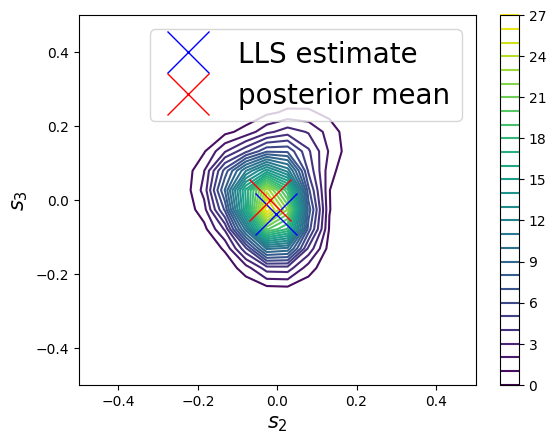

In [ ]:
# Contour Plot of the Samples
i,j=0, 1
plt.figure()
bw_method = .9
xmin, xmax = -.5, .5
ymin, ymax = -.5, .5
X, Y = np.mgrid[xmin:xmax:20j, ymin:ymax:20j]
positions = np.vstack([X.ravel(), Y.ravel()])
values = np.vstack([xx[:,i].T, xx[:,j].T])
kernel = stats.gaussian_kde(values, bw_method=bw_method)
Z = np.reshape(kernel(positions).T, X.shape)
CS = plt.contour(X, Y, Z, 30, linestyles='solid')
plt.colorbar()
plt.xlim([xmin, xmax])
plt.ylim([ymin, ymax])
# plt.plot(xx[:,i], xx[:,j], 'k.', markersize=5, label='samples')
plt.plot(estimate_lls[0, :].tolist()[i], estimate_lls[0, :].tolist()[j], 'bx', markersize=30, label='LLS estimate')
plt.plot(postmean[i], postmean[j], 'rx', markersize=30, label='posterior mean')
plt.legend(fontsize=20)
plt.xlabel('$s_1$',fontsize=15)
plt.ylabel('$s_2$',fontsize=15)
#plt.savefig('Results/Drosophila/Drosophila_hap_'+str(rep_ind)+'_'+str(i)+str(j)+'.png')
plt.show()
plt.close()

i,j=1,2
plt.figure()
bw_method = .9
xmin, xmax = -.5, .5
ymin, ymax = -.5, .5
X, Y = np.mgrid[xmin:xmax:20j, ymin:ymax:20j]
positions = np.vstack([X.ravel(), Y.ravel()])
values = np.vstack([xx[:,i].T, xx[:,j].T])
kernel = stats.gaussian_kde(values, bw_method=bw_method)
Z = np.reshape(kernel(positions).T, X.shape)
CS = plt.contour(X, Y, Z, 30, linestyles='solid')
plt.colorbar()
plt.xlim([xmin, xmax])
plt.ylim([ymin, ymax])
# plt.plot(xx[:,i], xx[:,j], 'k.', markersize=5, label='samples')
plt.plot(estimate_lls[0, :].tolist()[i], estimate_lls[0, :].tolist()[j], 'bx', markersize=30, label='LLS estimate')
plt.plot(postmean[i], postmean[j], 'rx', markersize=30, label='posterior mean')
plt.legend(fontsize=20)
plt.xlabel('$s_2$',fontsize=15)
plt.ylabel('$s_3$',fontsize=15)
#plt.savefig('Results/Drosophila/Drosophila_hap_'+str(rep_ind)+'_'+str(i)+str(j)+'.png')
plt.show()
plt.close()

i, j = 3,4
#print(i, j)
plt.figure()
bw_method = .9
# xmin, xmax = min(xx[:, i]) - 2* (max(xx[:, i])-min(xx[:, i])), max(xx[:, i]) + 2* (max(xx[:, i])-min(xx[:, i]))
# ymin, ymax = min(xx[:, j]) - 2* (max(xx[:, j])-min(xx[:, j])), max(xx[:, j]) + 2* (max(xx[:, j])-min(xx[:, j]))
xmin, xmax = max(0,min(xx[:, i]) - 2* (max(xx[:, i])-min(xx[:, i]))), min(1,max(xx[:, i]) + 2* (max(xx[:, i])-min(xx[:, i])))
ymin, ymax = max(0,min(xx[:, j]) - 2* (max(xx[:, j])-min(xx[:, j]))), min(1,max(xx[:, j]) + 2* (max(xx[:, j])-min(xx[:, j])))
X, Y = np.mgrid[xmin:xmax:20j, ymin:ymax:20j]
positions = np.vstack([X.ravel(), Y.ravel()])
values = np.vstack([xx[:, i].T, xx[:, j].T])
kernel = stats.gaussian_kde(values, bw_method=bw_method)
Z = np.reshape(kernel(positions).T, X.shape)
CS = plt.contour(X, Y, Z, 30, linestyles='solid')
plt.colorbar()
plt.xlim([xmin, xmax])
plt.ylim([ymin, ymax])
# plt.plot(xx[:,i], xx[:,j], 'k.', markersize=5, label='samples')
plt.plot(postmean[i], postmean[j], 'rx', markersize=30, label='posterior mean')
plt.legend(fontsize=20)
plt.xlabel('$h_1$', fontsize=15)
plt.ylabel('$h_2$', fontsize=15)
#plt.savefig('Results/Drosophila/Drosophila_hap_'+str(rep_ind)+'_'+str(i) + str(j) + '.png')
plt.show()
plt.close()

i, j = 5,6
#print(i, j)
plt.figure()
bw_method = .9
# xmin, xmax = min(xx[:, i]) - 2* (max(xx[:, i])-min(xx[:, i])), max(xx[:, i]) + 2* (max(xx[:, i])-min(xx[:, i]))
# ymin, ymax = min(xx[:, j]) - 2* (max(xx[:, j])-min(xx[:, j])), max(xx[:, j]) + 2* (max(xx[:, j])-min(xx[:, j]))
xmin, xmax = max(0,min(xx[:, i]) - 2* (max(xx[:, i])-min(xx[:, i]))), min(1,max(xx[:, i]) + 2* (max(xx[:, i])-min(xx[:, i])))
ymin, ymax = max(0,min(xx[:, j]) - 2* (max(xx[:, j])-min(xx[:, j]))), min(1,max(xx[:, j]) + 2* (max(xx[:, j])-min(xx[:, j])))
X, Y = np.mgrid[xmin:xmax:20j, ymin:ymax:20j]
positions = np.vstack([X.ravel(), Y.ravel()])
values = np.vstack([xx[:, i].T, xx[:, j].T])
kernel = stats.gaussian_kde(values, bw_method=bw_method)
Z = np.reshape(kernel(positions).T, X.shape)
CS = plt.contour(X, Y, Z, 30, linestyles='solid')
plt.colorbar()
plt.xlim([xmin, xmax])
plt.ylim([ymin, ymax])
# plt.plot(xx[:,i], xx[:,j], 'k.', markersize=5, label='samples')
plt.plot(postmean[i], postmean[j], 'rx', markersize=30, label='posterior mean')
plt.legend(fontsize=20)
plt.xlabel('$h_3$', fontsize=15)
plt.ylabel('$h_4$', fontsize=15)
#plt.savefig('Results/Drosophila/Drosophila_hap_'+str(rep_ind)+'_'+str(i) + str(j) + '.png')
plt.show()
plt.close()

i, j = 7,8
#print(i, j)
plt.figure()
bw_method = .9
# xmin, xmax = min(xx[:, i]) - 2* (max(xx[:, i])-min(xx[:, i])), max(xx[:, i]) + 2* (max(xx[:, i])-min(xx[:, i]))
# ymin, ymax = min(xx[:, j]) - 2* (max(xx[:, j])-min(xx[:, j])), max(xx[:, j]) + 2* (max(xx[:, j])-min(xx[:, j]))
xmin, xmax = max(0,min(xx[:, i]) - 2* (max(xx[:, i])-min(xx[:, i]))), min(1,max(xx[:, i]) + 2* (max(xx[:, i])-min(xx[:, i])))
ymin, ymax = max(0,min(xx[:, j]) - 2* (max(xx[:, j])-min(xx[:, j]))), min(1,max(xx[:, j]) + 2* (max(xx[:, j])-min(xx[:, j])))
X, Y = np.mgrid[xmin:xmax:20j, ymin:ymax:20j]
positions = np.vstack([X.ravel(), Y.ravel()])
values = np.vstack([xx[:, i].T, xx[:, j].T])
kernel = stats.gaussian_kde(values, bw_method=bw_method)
Z = np.reshape(kernel(positions).T, X.shape)
CS = plt.contour(X, Y, Z, 30, linestyles='solid')
plt.colorbar()
plt.xlim([xmin, xmax])
plt.ylim([ymin, ymax])
# plt.plot(xx[:,i], xx[:,j], 'k.', markersize=5, label='samples')
plt.plot(postmean[i], postmean[j], 'rx', markersize=30, label='posterior mean')
plt.legend(fontsize=20)
plt.xlabel('$h_5$', fontsize=15)
plt.ylabel('$h_6$', fontsize=15)
#plt.savefig('Results/Drosophila/Drosophila_hap_'+str(rep_ind)+'_'+str(i) + str(j) + '.png')
plt.show()
plt.close()

i, j = 9, 10
#print(i, j)
plt.figure()
bw_method = .9
# xmin, xmax = min(xx[:, i]) - 2* (max(xx[:, i])-min(xx[:, i])), max(xx[:, i]) + 2* (max(xx[:, i])-min(xx[:, i]))
# ymin, ymax = min(xx[:, j]) - 2* (max(xx[:, j])-min(xx[:, j])), max(xx[:, j]) + 2* (max(xx[:, j])-min(xx[:, j]))
xmin, xmax = max(0,min(xx[:, i]) - 2* (max(xx[:, i])-min(xx[:, i]))), min(1,max(xx[:, i]) + 2* (max(xx[:, i])-min(xx[:, i])))
ymin, ymax = max(0,min(xx[:, j]) - 2* (max(xx[:, j])-min(xx[:, j]))), min(1,max(xx[:, j]) + 2* (max(xx[:, j])-min(xx[:, j])))
X, Y = np.mgrid[xmin:xmax:20j, ymin:ymax:20j]
positions = np.vstack([X.ravel(), Y.ravel()])
values = np.vstack([xx[:, i].T, xx[:, j].T])
kernel = stats.gaussian_kde(values, bw_method=bw_method)
Z = np.reshape(kernel(positions).T, X.shape)
CS = plt.contour(X, Y, Z, 30, linestyles='solid')
plt.colorbar()
plt.xlim([xmin, xmax])
plt.ylim([ymin, ymax])
# plt.plot(xx[:,i], xx[:,j], 'k.', markersize=5, label='samples')
plt.plot(postmean[i], postmean[j], 'rx', markersize=30, label='posterior mean')
plt.legend(fontsize=20)
plt.xlabel('$h_7$', fontsize=15)
plt.ylabel('$h_8$', fontsize=15)
#plt.savefig('Results/Drosophila/Drosophila_hap_'+str(rep_ind)+'_'+str(i) + str(j) + '.png')
plt.show()
plt.close()